<a href="https://colab.research.google.com/github/nix-life/Monte-Carlo-Simulation/blob/main/quant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [54]:
start = "2018-01-01"
end = "2024-01-01"

stock = yf.download("AAPL", start=start, end=end)
market = yf.download("^GSPC", start=start, end=end) # GSPC is S&P 500 index

/tmp/ipython-input-145/3841212971.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-145/3841212971.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market = yf.download("^GSPC", start=start, end=end) # GSPC is S&P 500 index
[*********************100%***********************]  1 of 1 completed


In [55]:
data = pd.DataFrame(index=stock.index)
data["stock_returns"] = np.log(stock['Close'] / stock['Close'].shift(1))
data["market_returns"] = np.log(market['Close'] / market['Close'].shift(1))

data = data.dropna()

In [56]:
x = data["market_returns"]
y = data["stock_returns"]

x = sm.add_constant(x) # add alpha

In [57]:
model = sm.OLS(y, x)

results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:          stock_returns   R-squared:                       0.636
Model:                            OLS   Adj. R-squared:                  0.636
Method:                 Least Squares   F-statistic:                     2629.
Date:                Mon, 02 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:39:31   Log-Likelihood:                 4524.3
No. Observations:                1508   AIC:                            -9045.
Df Residuals:                    1506   BIC:                            -9034.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0006      0.000      1.

In [58]:
results_hac = model.fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 5}
)
print(results_hac.summary())

                            OLS Regression Results                            
Dep. Variable:          stock_returns   R-squared:                       0.636
Model:                            OLS   Adj. R-squared:                  0.636
Method:                 Least Squares   F-statistic:                     910.3
Date:                Mon, 02 Mar 2026   Prob (F-statistic):          8.31e-157
Time:                        17:39:31   Log-Likelihood:                 4524.3
No. Observations:                1508   AIC:                            -9045.
Df Residuals:                    1506   BIC:                            -9034.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0006      0.000      1.

In [59]:
window = 21  # ~1 trading month

data["rolling_vol"] = (
    data["stock_returns"]
    .rolling(window)
    .std()
)

window = 21

data["market_rolling_vol"] = (
    data["market_returns"]
    .rolling(window)
    .std()
)

<Axes: title={'center': '21-Day Rolling Volatility'}, xlabel='Date'>

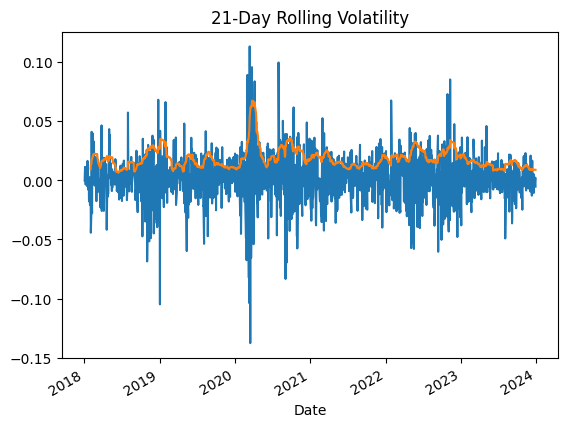

In [60]:
data["stock_returns"].plot(title="Daily Log Returns")
data["rolling_vol"].plot(title="21-Day Rolling Volatility")

<Axes: title={'center': 'Stock vs Market Rolling Volatility'}, xlabel='Date'>

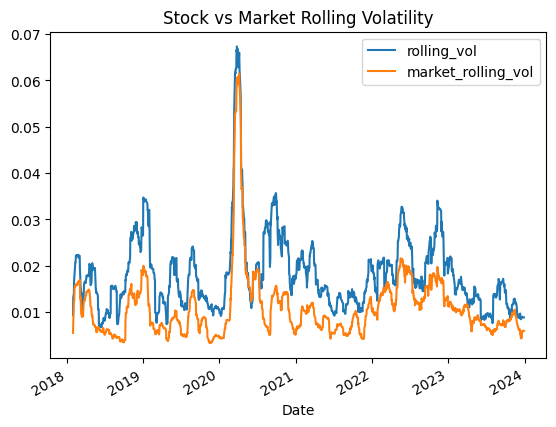

In [61]:
data[["rolling_vol", "market_rolling_vol"]].plot(
    title="Stock vs Market Rolling Volatility"
)

In [62]:
data["residuals"] = results.resid
data["resid_rolling_vol"] = (
    data["residuals"]
    .rolling(window)
    .std()
)

<Axes: title={'center': 'Total vs Residual Rolling Volatility'}, xlabel='Date'>

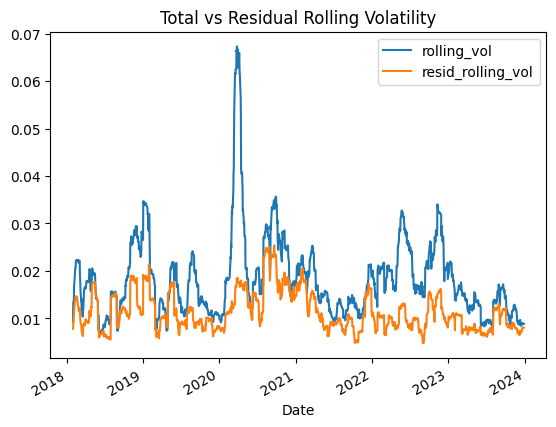

In [64]:
data[["rolling_vol", "resid_rolling_vol"]].plot(
    title="Total vs Residual Rolling Volatility"
)

In [65]:
results.resid.mean()

np.float64(-2.576777577047777e-19)

In [66]:
window = 60  # ~3 trading months

data["rolling_beta"] = (
    data["stock_returns"]
    .rolling(window)
    .cov(data["market_returns"])
    / data["market_returns"].rolling(window).var()
)

np.float64(1.3008637936212972)

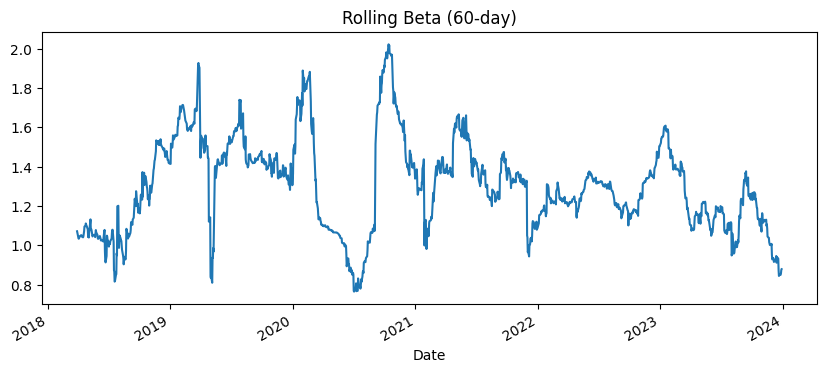

In [67]:
data["rolling_beta"].plot(
    title="Rolling Beta (60-day)",
    figsize=(10, 4)
)
data["rolling_beta"].mean()

# Monte Carlo

/tmp/ipython-input-145/1432012616.py:53: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2023-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Estimated annual volatility: 46.79%
Black–Scholes Call Price: 10.40

Simulations | MC Price | Difference from BS
--------------------------------------------------
       1000 |     9.87 | -0.5331
       5000 |    10.59 |  0.1919
      10000 |    10.23 | -0.1712
      50000 |    10.48 |  0.0766
     100000 |    10.47 |  0.0676


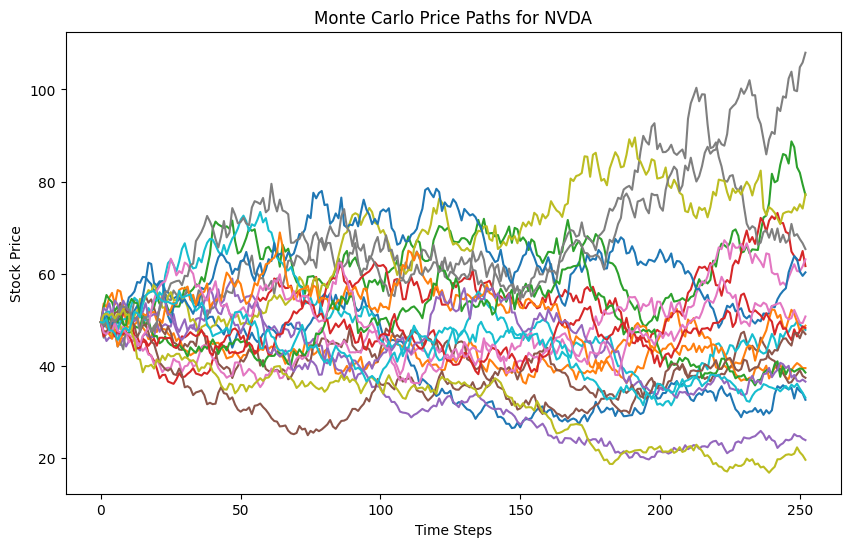

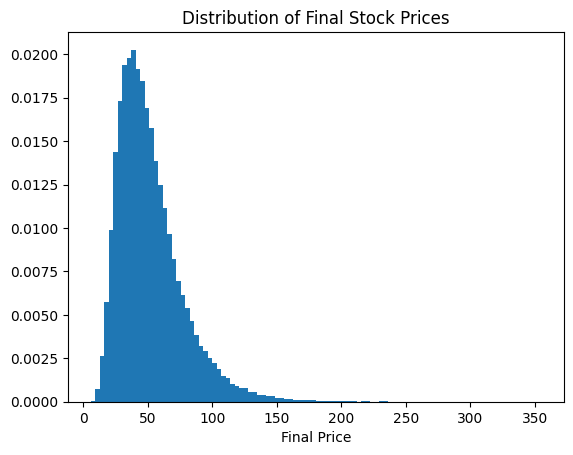


--- STABLE GREEKS ---
Monte Carlo Delta: 0.6406
Monte Carlo Gamma: 0.016184


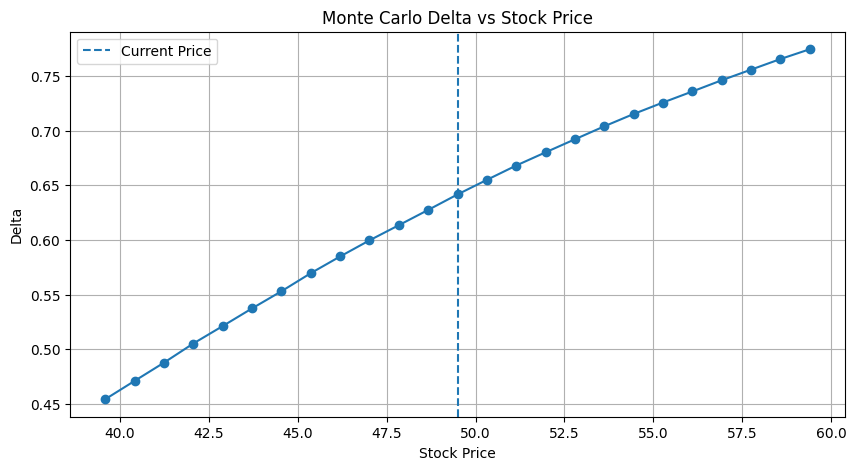

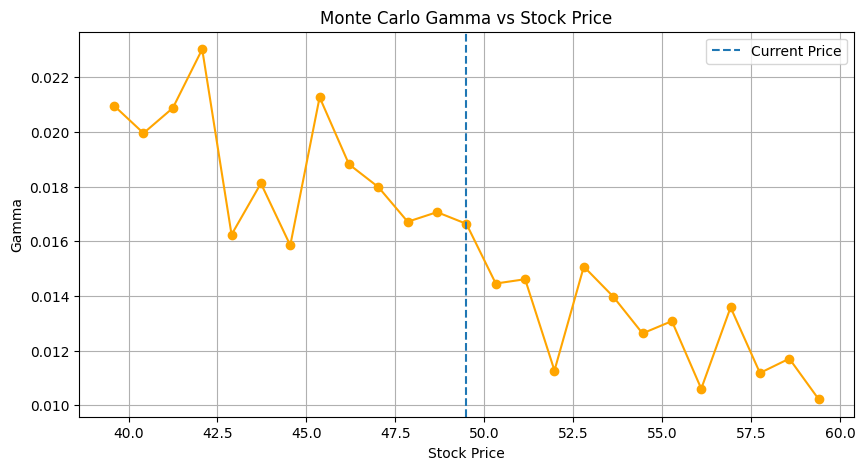


Delta-Hedged P&L: -9.75
Black–Scholes Delta:        0.6414
Monte Carlo Delta:          0.6406
Difference:                -0.0008


In [1]:
# IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm

def monte_carlo_call_price(S0, K, r, sigma, T, N, M):
    dt = T / N

    Z = np.random.standard_normal((M, N))

    S = np.zeros((M, N + 1))
    S[:, 0] = S0

    for t in range(1, N + 1):
        S[:, t] = S[:, t-1] * np.exp(
            (r - 0.5 * sigma**2) * dt
            + sigma * np.sqrt(dt) * Z[:, t-1]
        )

    ST = S[:, -1]
    payoffs = np.maximum(ST - K, 0)

    return np.exp(-r * T) * np.mean(payoffs)

def monte_carlo_call_price_with_Z(S0, K, r, sigma, T, N, Z):
    dt = T / N
    M = Z.shape[0]

    S = np.zeros((M, N + 1))
    S[:, 0] = S0

    for t in range(1, N + 1):
        S[:, t] = S[:, t-1] * np.exp(
            (r - 0.5 * sigma**2) * dt
            + sigma * np.sqrt(dt) * Z[:, t-1]
        )

    ST = S[:, -1]
    payoffs = np.maximum(ST - K, 0)

    return np.exp(-r * T) * np.mean(payoffs)

def black_scholes_delta_call(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

# 1. DOWNLOAD REAL STOCK DATA

ticker = "NVDA"

data = yf.download(ticker, start="2023-01-01", end="2024-01-01")
prices = data["Close"]

S0 = prices.iloc[-1].item()   # Current stock price (as scalar)

# 2. ESTIMATE VOLATILITY FROM REAL DATA

log_returns = np.log(prices / prices.shift(1)).dropna()

sigma = log_returns.std() * np.sqrt(252)

print(f"Estimated annual volatility: {sigma.item():.2%}")

# 3. OPTION & MODEL PARAMETERS

K = round(S0)     # At-the-money option (now S0 is scalar, K will be int)
r = 0.05          # Risk-free rate
T = 1.0           # 1 year to maturity

N = 252           # Time steps (days)
dt = T / N

# 4. BLACK–SCHOLES (REFERENCE PRICE)

def black_scholes_call(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

bs_price = black_scholes_call(S0, K, r, sigma.item(), T)

print(f"Black–Scholes Call Price: {bs_price:.2f}")


# 5. MONTE CARLO CONVERGENCE TEST

simulation_sizes = [1_000, 5_000, 10_000, 50_000, 100_000]

print("\nSimulations | MC Price | Difference from BS")
print("-" * 50)

for M in simulation_sizes:

    # Generate random shocks
    Z = np.random.standard_normal((M, N))

    # Stock price paths
    S = np.zeros((M, N + 1))
    S[:, 0] = S0

    for t in range(1, N + 1):
        S[:, t] = S[:, t-1] * np.exp(
            (r - 0.5 * sigma.item()**2) * dt
            + sigma.item() * np.sqrt(dt) * Z[:, t-1]
        )

    # Final prices
    ST = S[:, -1]

    # Option payoff
    payoffs = np.maximum(ST - K, 0) # K is already scalar here

    # Discounted Monte Carlo price
    mc_price = np.exp(-r * T) * np.mean(payoffs)

    diff = mc_price - bs_price

    print(f"{M:11d} | {mc_price:8.2f} | {diff: .4f}")


# 6. VISUALIZATION (OPTIONAL BUT IMPORTANT)

# Plot some price paths
plt.figure(figsize=(10, 6))
for i in range(20):
    plt.plot(S[i])
plt.title(f"Monte Carlo Price Paths for {ticker}")
plt.xlabel("Time Steps")
plt.ylabel("Stock Price")
plt.show()

# Distribution of final prices
plt.hist(ST, bins=100, density=True)
plt.title("Distribution of Final Stock Prices")
plt.xlabel("Final Price")
plt.show()

# 7. STABLE DELTA & GAMMA (COMMON RANDOM NUMBERS)

M_greeks = 200_000
bump = 0.05

# ONE shared random matrix
Z_common = np.random.standard_normal((M_greeks, N))

price_down = monte_carlo_call_price_with_Z(
    S0 - bump, K, r, sigma.item(), T, N, Z_common
)

price_mid = monte_carlo_call_price_with_Z(
    S0, K, r, sigma.item(), T, N, Z_common
)

price_up = monte_carlo_call_price_with_Z(
    S0 + bump, K, r, sigma.item(), T, N, Z_common
)

delta_mc = (price_up - price_mid) / bump

delta_down = (price_mid - price_down) / bump
delta_up = (price_up - price_mid) / bump

gamma_mc = (delta_up - delta_down) / bump

print("\n--- STABLE GREEKS ---")
print(f"Monte Carlo Delta: {delta_mc:.4f}")
print(f"Monte Carlo Gamma: {gamma_mc:.6f}")

# 8. DELTA & GAMMA VS STOCK PRICE (VISUALIZATION)

price_range = np.linspace(0.8 * S0, 1.2 * S0, 25)
bump = 0.05
M_plot = 100_000

Z_common = np.random.standard_normal((M_plot, N))

delta_values = []
gamma_values = []

for S_test in price_range:

    price_down = monte_carlo_call_price_with_Z(
        S_test - bump, K, r, sigma.item(), T, N, Z_common
    )

    price_mid = monte_carlo_call_price_with_Z(
        S_test, K, r, sigma.item(), T, N, Z_common
    )

    price_up = monte_carlo_call_price_with_Z(
        S_test + bump, K, r, sigma.item(), T, N, Z_common
    )

    delta = (price_up - price_mid) / bump

    delta_down = (price_mid - price_down) / bump
    delta_up = (price_up - price_mid) / bump

    gamma = (delta_up - delta_down) / bump

    delta_values.append(delta)
    gamma_values.append(gamma)

# PLOT DELTA
plt.figure(figsize=(10, 5))
plt.plot(price_range, delta_values, marker="o")
plt.axvline(S0, linestyle="--", label="Current Price")
plt.title("Monte Carlo Delta vs Stock Price")
plt.xlabel("Stock Price")
plt.ylabel("Delta")
plt.legend()
plt.grid()
plt.show()

# PLOT GAMMA
plt.figure(figsize=(10, 5))
plt.plot(price_range, gamma_values, marker="o", color="orange")
plt.axvline(S0, linestyle="--", label="Current Price")
plt.title("Monte Carlo Gamma vs Stock Price")
plt.xlabel("Stock Price")
plt.ylabel("Gamma")
plt.legend()
plt.grid()
plt.show()

# 9. DELTA HEDGING SIMULATION (ONE PATH)

np.random.seed(42)

Z_path = np.random.standard_normal(N)

S_path = np.zeros(N + 1)
S_path[0] = S0

for t in range(1, N + 1):
    S_path[t] = S_path[t-1] * np.exp(
        (r - 0.5 * sigma.item()**2) * dt
        + sigma.item() * np.sqrt(dt) * Z_path[t-1]
    )

cash = 0.0
stock_position = 0.0

# One shared random matrix for Greeks
M_hedge = 50_000
Z_common = np.random.standard_normal((M_hedge, N))

deltas = []

for t in range(N):
    T_remaining = T - t * dt
    if T_remaining <= 0:
        break

    bump = 0.05

    price_down = monte_carlo_call_price_with_Z(
        S_path[t] - bump, K, r, sigma.item(), T_remaining, N, Z_common
    )

    price_mid = monte_carlo_call_price_with_Z(
        S_path[t], K, r, sigma.item(), T_remaining, N, Z_common
    )

    price_up = monte_carlo_call_price_with_Z(
        S_path[t] + bump, K, r, sigma.item(), T_remaining, N, Z_common
    )

    delta = (price_up - price_mid) / bump
    deltas.append(delta)

    # Adjust stock position
    delta_change = delta - stock_position
    cash -= delta_change * S_path[t]
    stock_position = delta

# Option payoff (short call)
option_payoff = -max(S_path[-1] - K, 0)

# Close stock position
cash += stock_position * S_path[-1]

total_pnl = cash + option_payoff

print(f"\nDelta-Hedged P&L: {total_pnl:.2f}")

# VALIDATION
bs_delta = black_scholes_delta_call(
    S0, K, r, sigma.item(), T
)

print(f"Black–Scholes Delta:        {bs_delta:.4f}")
print(f"Monte Carlo Delta:          {delta_mc:.4f}")
print(f"Difference:                {delta_mc - bs_delta:.4f}")